# This notebook is used to perform curve-fit on subtlety data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_curvefit import *

## Preprocess dataFrame

In [5]:
sesID = 2 # 1 or 2

In [7]:
df_data = pd.read_csv(f'../../data/subtlety_data/all_apr_ses{sesID}.csv',index_col=[0]) 
df_data

,condition,subtlety,slider,RT,accuracy,subID,trial_ind
stim_file,,,,,,,
7d329546-ecf4-4612-8f00-c127c77d5d6c,chase,60,100.0,2.264,1,265,0
68be0cf8-ea92-4566-b84a-cbd60b2e5547,wander,180,19.0,3.469,1,265,1
884bc951-67a6-42bd-8ea7-ece0c8745d3f,chase,0,100.0,2.826,1,265,2
24724e9a-8a79-4ab8-a58f-e007c5d00714,chase,120,95.0,3.256,1,265,3
cd9d4d31-b57e-4c3d-86c6-267ce9eec948,chase,60,100.0,2.497,1,265,4
...,...,...,...,...,...,...,...
cd35aaa0-2e49-4c68-9db3-f26fb9be29c5,chase,0,85.0,3.054,1,173,79
65c87d60-ca32-4b8c-862c-41cd8e585b4b,chase,0,88.0,2.589,1,173,80
bc18f2bb-8e1a-4fcf-bc63-d56da485f828,chase,90,83.0,2.673,1,173,81


In [8]:
subs = np.unique(df_data['subID'])
print(len(subs))

240


In [9]:
subtlety = np.unique(df_data['subtlety'])
subtlety

array([  0,  30,  60,  90, 120, 150, 180])

In [10]:
df_mean = df_data.groupby(['subID','subtlety']).mean().reset_index()
df_mean

,subID,subtlety,slider,RT,accuracy,trial_ind
0,2,0,96.416667,2.580917,1.000000,37.416667
1,2,30,90.250000,2.551667,1.000000,44.750000
2,2,60,82.250000,2.498750,1.000000,48.083333
3,2,90,67.000000,2.430500,1.000000,37.083333
4,2,120,50.000000,2.943750,1.000000,40.250000
...,...,...,...,...,...,...
1675,344,60,98.000000,2.563333,1.000000,40.416667
1676,344,90,69.833333,2.555083,1.000000,39.583333
1677,344,120,42.916667,2.930250,0.833333,42.583333
1678,344,150,22.000000,2.597667,0.666667,41.000000


In [11]:
len(np.unique(df_mean['subID']))

240

## Curve-fit

In [12]:
good_fit = 0.8
nRep = 1000
param_bounds = [(0, 1), (0.0001, 10)]

nsub = len(subs)#350
print('nsub:',nsub)
params_name = ['subID', 'r_squared', 'nrmse','aic',
               'center', 'sigma', 'bias_lower', 'bias_upper',
               'center_y', 'obj_center', 'bias_xmin', 'bias_xmax', 'flipped']
df_params = pd.DataFrame(np.zeros((nsub, len(params_name))) * np.nan, columns=params_name)

nsub: 240


In [13]:
df_mean.head()

,subID,subtlety,slider,RT,accuracy,trial_ind
0,2,0,96.416667,2.580917,1.0,37.416667
1,2,30,90.250000,2.551667,1.0,44.750000
2,2,60,82.250000,2.498750,1.0,48.083333
3,2,90,67.000000,2.430500,1.0,37.083333
4,2,120,50.000000,2.943750,1.0,40.250000


In [16]:
rootfile_data = f'../../data/subtlety_data/curve_fit_subt_ses{sesID}/'

isub: 0 , subID: 2
isub: 50 , subID: 75
isub: 100 , subID: 150
isub: 150 , subID: 217
isub: 200 , subID: 282


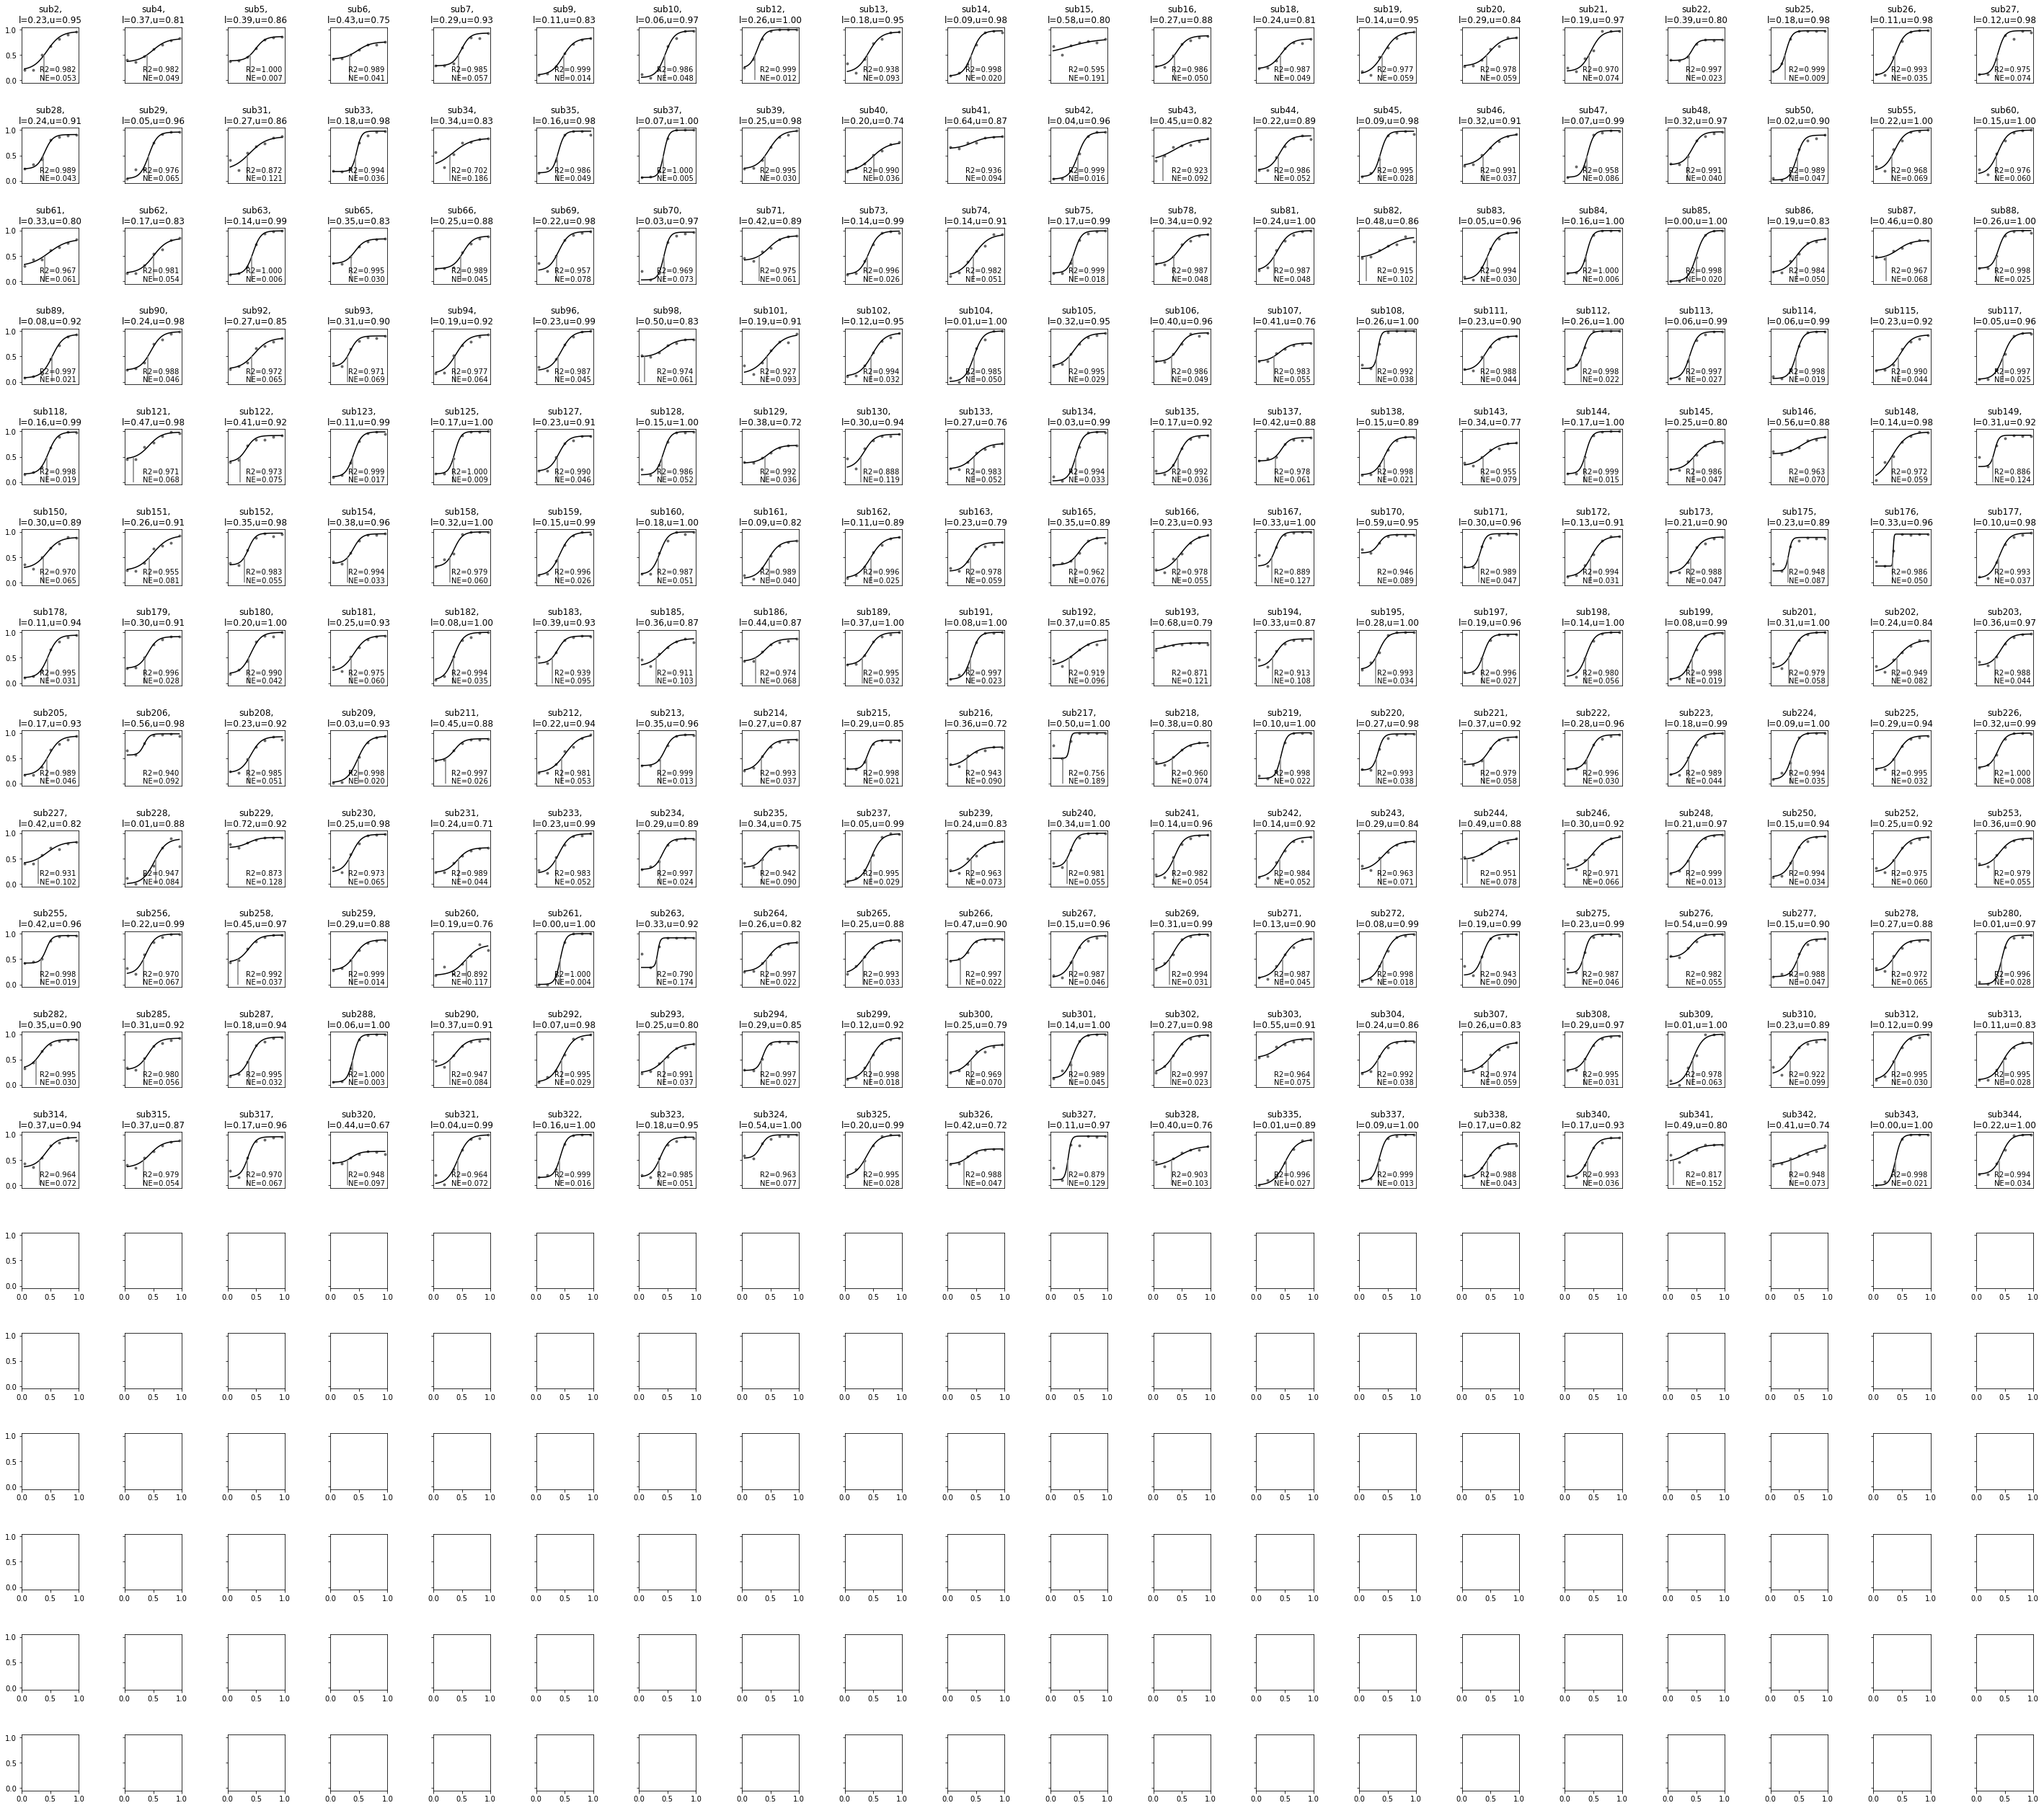

In [17]:
warnings.filterwarnings("ignore")
nrows = 18
ncols = 20
jitter_strength = .01
fig, axs  = plt.subplots(figsize = (50,45), nrows=nrows, ncols = ncols, sharey = True, sharex = False)
best_fit_params = []
subID = []
for isub,subID in enumerate(subs):
    df_params['subID'][isub] = subID #isub + 1
    if isub%50 == 0:
        print('isub:',isub, ', subID:', subID)
    ax = plt.subplot(nrows, ncols, isub+1)
    
    xfit = (180 - df_mean.loc[df_mean['subID'] == subID, 'subtlety'].values) / 180
    yfit = df_mean.loc[df_mean['subID'] == subID, 'slider'].values / 100

    x = np.array(xfit)
    y = np.array(yfit)

    flipped = False
    if y[x == 0] - y[x == 1] > .001: # flipped subs (curve shape opposite of that expected)
        flipped =  True
        x = np.flip(x)
        print('flipped', subID)

    # try:
    results = fit_sigmoid(x, y, rescale=True, padding=False, n_rep=nRep, param_bounds=param_bounds,
                param_details=f"{rootfile_data}/sub%d_1k_subt.csv"%(subID))
    best_params, goodness_of_fit, other_params = results

    ss_res, df_params['nrmse'][isub], df_params['r_squared'][isub],df_params['aic'][isub] = goodness_of_fit
    
    if flipped == False:
        df_params['center'][isub], df_params['sigma'][isub], df_params['bias_lower'][isub], df_params['bias_upper'][isub] = best_params
        df_params['center_y'][isub], df_params['obj_center'][isub], df_params['bias_xmin'][isub], df_params['bias_xmax'][isub] = other_params
    else: # socialness DEcreases with inv_subtlety (unexpected)
        print('flipped')
        df_params['center'][isub], df_params['sigma'][isub], df_params['bias_upper'][isub], df_params['bias_lower'][isub] = best_params
        df_params['center_y'][isub], df_params['obj_center'][isub], df_params['bias_xmax'][isub], df_params['bias_xmin'][isub] = other_params
        df_params['bias_upper'][isub] = 1 - df_params['bias_upper'][isub]
        df_params['bias_lower'][isub] = 1 - df_params['bias_lower'][isub]
        df_params['bias_xmax'][isub] = 1 - df_params['bias_xmax'][isub]
        df_params['bias_xmin'][isub] = 1 - df_params['bias_xmin'][isub]
        # e.g. if the curve goes from .8 to .2, bias_xmin should be 0.8. flipped curve will give bias_xmax as 0.2 
        # (on the flipped version of the true curve) which when flipped (i.e., assigned to bias_xmin) and then subtracted from 1 gives us a bias_xmin of 0.8
    
    df_params['flipped'][isub] = flipped

    if np.isnan(df_params['obj_center'][isub]):
        if (df_params['bias_xmin'][isub] >= 0.5) & (df_params['bias_xmax'][isub] <= 0.5):
            obj_center = 0 if flipped == False else 1
        elif (df_params['bias_xmax'][isub] >= 0.5) & (df_params['bias_xmin'][isub] <= 0.5):
            obj_center = 1 if flipped == False else 0
    
    plot_curve_fit(ax, x, y, best_params, color='black', text_loc=(0.3, 0))

    ax.vlines(df_params['obj_center'][isub],0,.5,color='grey')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    # ax.set_xticks(np.arange(0,1.1,.2))
    if flipped:
        ax.invert_xaxis()
        df_params['center_y'][isub] = 1-df_params['center_y'][isub] # do this ONLY AFTER plotting
        df_params['obj_center'][isub] = 1-df_params['obj_center'][isub]
    ax.set_title(f"sub{subID},\nl={df_params['bias_xmin'][isub]:.2f},u={1-df_params['bias_xmax'][isub]:.2f}")
    ax.set_xticks([])
    # except:
    #     print('bad', subID)
    #     continue

    # break

plt.subplots_adjust(wspace=0.8, hspace=0.8)
plt.savefig(f'../../results/subtlety/curvefit_subtlety_ses{sesID}.png')
df_params[['subID', 'r_squared', 'nrmse', 'aic', 'center', 'obj_center', 'sigma', 'bias_xmin', 'bias_xmax', 'bias_lower', 'bias_upper','flipped']].to_csv(f'{rootfile_data}/all_params_1k_subt.csv', index = False)

In [18]:
df_params.sort_values(by=['r_squared']).head()

,subID,r_squared,nrmse,aic,center,sigma,bias_lower,bias_upper,center_y,obj_center,bias_xmin,bias_xmax,flipped
10,15.0,0.594764,0.190694,-19.199227,0.313610,0.271394,0.507500,0.177500,0.665000,NaN,0.582935,2.007600e-01,False
24,34.0,0.701998,0.186116,-19.539388,0.334164,0.176329,0.267500,0.157500,0.555000,0.265858,0.342631,1.703793e-01,False
150,217.0,0.755780,0.188673,-19.348364,0.318236,0.020802,0.499167,0.000000,0.749583,0.185164,0.499167,2.886580e-15,False
186,263.0,0.790321,0.173743,-20.502528,0.310641,0.024346,0.334167,0.081667,0.626250,0.288114,0.334168,8.166667e-02,False
236,341.0,0.816773,0.151962,-22.377758,0.342403,0.146806,0.456667,0.195833,0.630417,0.056328,0.487413,1.997300e-01,False


In [19]:
df_params.sort_values(by=['r_squared'])

,subID,r_squared,nrmse,aic,center,sigma,bias_lower,bias_upper,center_y,obj_center,bias_xmin,bias_xmax,flipped
10,15.0,0.594764,0.190694,-19.199227,0.313610,0.271394,0.507500,0.177500,0.665000,NaN,0.582935,2.007600e-01,False
24,34.0,0.701998,0.186116,-19.539388,0.334164,0.176329,0.267500,0.157500,0.555000,0.265858,0.342631,1.703793e-01,False
150,217.0,0.755780,0.188673,-19.348364,0.318236,0.020802,0.499167,0.000000,0.749583,0.185164,0.499167,2.886580e-15,False
186,263.0,0.790321,0.173743,-20.502528,0.310641,0.024346,0.334167,0.081667,0.626250,0.288114,0.334168,8.166667e-02,False
236,341.0,0.816773,0.151962,-22.377758,0.342403,0.146806,0.456667,0.195833,0.630417,0.056328,0.487413,1.997300e-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,63.0,0.999832,0.005823,-68.042015,0.441724,0.075111,0.133333,0.006667,0.563333,0.419436,0.135728,7.175127e-03,False
55,84.0,0.999851,0.005677,-68.398106,0.379142,0.055761,0.160833,0.000833,0.580000,0.357593,0.161767,8.455751e-04,False
26,37.0,0.999890,0.005462,-68.940125,0.427637,0.047409,0.067500,0.000000,0.533750,0.420761,0.067613,5.326807e-06,False
185,261.0,0.999913,0.004235,-72.502000,0.416511,0.051572,0.000000,0.000000,0.500000,0.416511,0.000311,1.219928e-05,False


In [20]:
df_params.loc[df_params['r_squared']<0,:]

,subID,r_squared,nrmse,aic,center,sigma,bias_lower,bias_upper,center_y,obj_center,bias_xmin,bias_xmax,flipped


In [21]:
df_corr = df_params[['r_squared','sigma','center','obj_center','bias_xmax','bias_xmin']].corr()
df_corr

,r_squared,sigma,center,obj_center,bias_xmax,bias_xmin
r_squared,1.000000,-0.341375,0.266735,0.332869,-0.257289,-0.404371
sigma,-0.341375,1.000000,0.379796,0.020068,0.536613,0.288111
center,0.266735,0.379796,1.000000,0.637747,0.247548,-0.221167
obj_center,0.332869,0.020068,0.637747,1.000000,0.024019,-0.706692
bias_xmax,-0.257289,0.536613,0.247548,0.024019,1.000000,0.395290
bias_xmin,-0.404371,0.288111,-0.221167,-0.706692,0.395290,1.000000


In [22]:
import seaborn as sns

Text(0.5, 1.0, 'with bad fits too!')

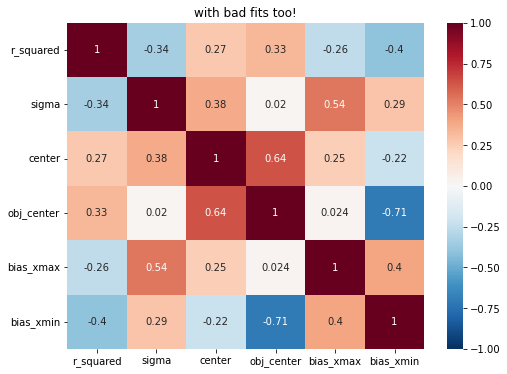

In [23]:
plt.figure(figsize = (8,6))
sns.heatmap(df_corr,cmap='RdBu_r',vmin=-1,vmax=1,annot=True)
plt.yticks(rotation = 0)
plt.title('with bad fits too!')

<AxesSubplot:xlabel='sigma', ylabel='r_squared'>

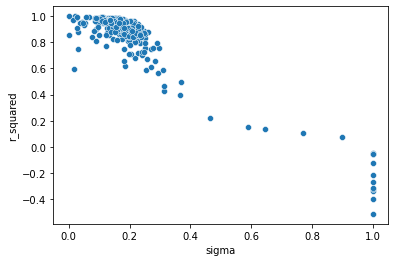

In [ ]:
sns.scatterplot(data = df_params,x = 'sigma', y ='r_squared')

In [ ]:
df_clean = df_params.loc[df_params['r_squared']>=.8,:]
df_clean.shape

(269, 11)

In [27]:
df_clean.loc[np.isinf(df_clean['obj_center']),:]

,subID,r_squared,nrmse,center,sigma,bias_lower,bias_upper,center_y,obj_center,bias_xmin,bias_xmax


In [28]:
obj_center = []
for i,row in df_clean.iterrows():
    if np.isinf(row['obj_center']):
        if np.round(row['bias_xmax'],4) <= .5:
            obj_center.append(1)
        elif np.round(row['bias_xmin'],4) >= .5:
            obj_center.append(0)
    else:
        obj_center.append(row['obj_center'])
df_clean['obj_center'] = obj_center

In [29]:
df_clean = df_clean.loc[~np.isinf(df_clean['obj_center']),:]
df_clean.shape

(269, 11)

In [30]:
df_corr = df_clean[['r_squared','sigma','center','obj_center','bias_xmax','bias_xmin']].corr()
df_corr

,r_squared,sigma,center,obj_center,bias_xmax,bias_xmin
r_squared,1.000000,-0.400929,-0.017754,-0.121227,-0.215882,-0.375940
sigma,-0.400929,1.000000,0.263532,0.138017,0.066750,0.255132
center,-0.017754,0.263532,1.000000,0.613086,0.179023,-0.239330
obj_center,-0.121227,0.138017,0.613086,1.000000,0.695785,-0.193919
bias_xmax,-0.215882,0.066750,0.179023,0.695785,1.000000,0.241933
bias_xmin,-0.375940,0.255132,-0.239330,-0.193919,0.241933,1.000000


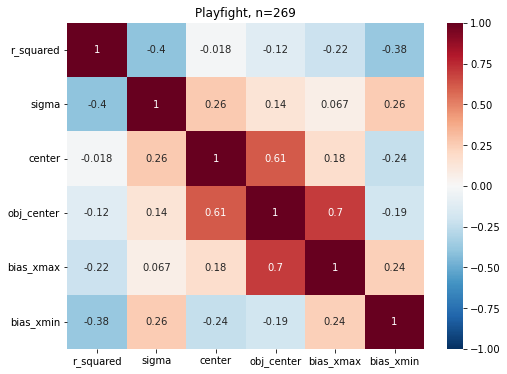

In [31]:
plt.figure(figsize = (8,6))
sns.heatmap(df_corr,cmap='RdBu_r',vmin=-1,vmax=1,annot=True)
plt.title(f'Playfight, n={df_clean.shape[0]}')
plt.yticks(rotation = 0)
plt.savefig('../results/covariance_matrix_curvefit.png')

<AxesSubplot:xlabel='sigma', ylabel='r_squared'>

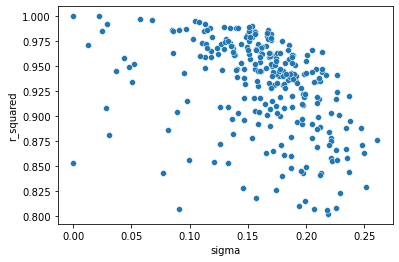

In [32]:
sns.scatterplot(data = df_clean,x = 'sigma', y ='r_squared')

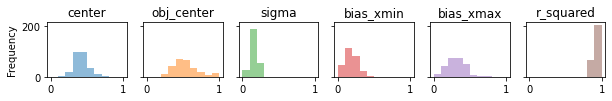

In [33]:
plot_curve_param = ['center', 'obj_center', 'sigma', 'bias_xmin', 'bias_xmax', 'r_squared']
df_clean[plot_curve_param].plot(kind='hist', bins=10, subplots=True, sharex=False, sharey=True, layout=(1,len(plot_curve_param)), legend=False, title=plot_curve_param, figsize=(10,1), alpha=0.5)
plt.savefig('../results/curvefit_histograms.png', bbox_inches="tight" )

In [36]:
from scipy import stats

0.24193314418091127 6.091446676500081e-05


Text(0.1, 0.9, 'r=0.24 (p < .001)')

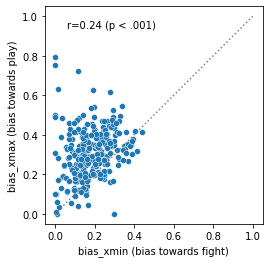

In [38]:
sns.scatterplot(data = df_clean, x = 'bias_xmin',y = 'bias_xmax')
plt.gca().set_aspect('equal', adjustable='box')
plt.plot([0,1],[0,1], color ='grey',ls = ':')
plt.xlabel('bias_xmin (bias towards fight)')
plt.ylabel('bias_xmax (bias towards play)')
r,p = stats.pearsonr(df_clean['bias_xmin'], df_clean['bias_xmax'])
print(r,p)
plt.gca().annotate(f'r={r:.2f} (p < .001)',xy = (0.1,.9),xycoords = 'axes fraction')

<AxesSubplot:>

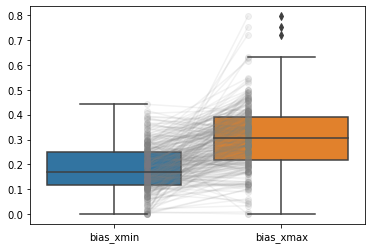

In [39]:
for _, row in df_clean.iterrows():
    plt.plot([0.2, .8], [row['bias_xmin'], row['bias_xmax']], '-o', color='grey', alpha = .1)
sns.boxplot(data = df_clean[['bias_xmin','bias_xmax']])

In [40]:
from scipy import stats

In [41]:
(df_clean['bias_xmax'] - df_clean['bias_xmin']).mean()

0.12606897272032674

In [42]:
stats.ttest_rel(df_clean['bias_xmin'],df_clean['bias_xmax'])

Ttest_relResult(statistic=-14.793591646302325, pvalue=1.312835566271599e-36)

In [43]:
df_clean['center'].describe()

count    269.000000
mean       0.419375
std        0.104761
min        0.000100
25%        0.355657
50%        0.416549
75%        0.479684
max        0.772257
Name: center, dtype: float64

In [44]:
from pymer4.models import Lmer,Lm
from pymer4.stats import vif

In [45]:
def vif_info(model):
    design_matrix_df = model.design_matrix
    #design_matrix_df.shape
    # print('model:', model.formula)
    vif_keys= list(vif(design_matrix_df)[1].keys())
    vif_values= list(vif(design_matrix_df)[1].values())
    print('VIF: ',','.join([vif_keys[i] + ': ' + str(np.round(vif_values[i],2)) for i in range(len(vif_keys))]))
    # print('AIC: ', model.AIC)

In [46]:
model = Lm('subID ~ center + sigma  + bias_xmin  + bias_xmax' , data=df_params) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

VIF:  center: 1.26,sigma: 1.57,bias_xmin: 1.29,bias_xmax: 1.32


In [47]:
rows = ~np.isnan(df_params['obj_center']) & ~np.isinf(df_params['obj_center'])
model = Lm('subID ~ center + sigma  + bias_xmin  + bias_xmax' , data=df_params.loc[rows,:]) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

VIF:  center: 1.26,sigma: 1.57,bias_xmin: 1.29,bias_xmax: 1.32


In [48]:
rows = ~np.isnan(df_params['obj_center']) & ~np.isinf(df_params['obj_center'])
model = Lm('subID ~ obj_center + sigma  + bias_xmin  + bias_xmax' , data=df_params.loc[rows,:]) # ff: anglesm rfx: subject ID
model.fit(summary=False)
vif_info(model)

VIF:  obj_center: 2.74,sigma: 1.43,bias_xmin: 1.56,bias_xmax: 2.9


In [ ]:
X

In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cf_params_1 = ["sigma","center", "bias_xmax", "bias_xmin"]
X = df_params[cf_params_1]
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X.reset_index()
# X.drop(columns=['index'],inplace=True)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

     feature        VIF
0      index   3.526623
1      sigma   5.310976
2     center   9.753847
3  bias_xmax  10.472256
4  bias_xmin   6.942190


In [111]:
X.drop(columns=['index'],inplace=True)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

     feature        VIF
0      sigma   5.310876
1     center   8.778918
2  bias_xmax  10.376944
3  bias_xmin   6.817238


In [124]:
np.where(np.isnan(X))

(array([], dtype=int64), array([], dtype=int64))

In [112]:
from pymer4.stats import vif
vif(X,has_intercept=False)

({},
 {'sigma': 1.761860767424135,
  'center': 1.4481021328207617,
  'bias_xmax': 1.3359210419614593,
  'bias_xmin': 1.6410180332850042})

In [73]:
cf_params_1 = ["sigma","obj_center", "bias_xmax", "bias_xmin"]
X = df_params[cf_params_1]
X = X.replace([np.inf, -np.inf], np.nan).dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

      feature        VIF
0       sigma   6.056342
1  obj_center  12.386012
2   bias_xmax  16.796136
3   bias_xmin   8.257309


In [76]:
X.columns

Index(['sigma', 'obj_center', 'bias_xmax', 'bias_xmin'], dtype='object')

In [75]:
i = X.columns[0]
i

'sigma'

In [78]:
X.values.shape

(289, 4)

In [96]:
# Assuming X is your design matrix
if isinstance(X, pd.DataFrame):
    features = X.columns
else:
    features = range(X.shape[1])

VIFs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

for feature, vif in zip(features, VIFs):
    print(f"VIF for {feature}: {vif}")


VIF for sigma: 5.310876132164404
VIF for center: 8.778917662271116
VIF for bias_xmax: 10.376943546437964
VIF for bias_xmin: 6.817237590004739


In [84]:
# from pymer4.stats import vif

# vif(X,has_intercept=False)

({},
 {'sigma': 1.8406606114996829,
  'obj_center': 2.199136287843744,
  'bias_xmax': 2.075913409051268,
  'bias_xmin': 2.0052263572275923})

In [83]:

# vif(X,has_intercept=False, exclude_intercept=False)

({},
 {'sigma': 1.8406606114996829,
  'obj_center': 2.199136287843744,
  'bias_xmax': 2.075913409051268,
  'bias_xmin': 2.0052263572275923})

In [87]:

# vif(X,has_intercept=False, exclude_intercept=True)

({},
 {'sigma': 1.8406606114996829,
  'obj_center': 2.199136287843744,
  'bias_xmax': 2.075913409051268,
  'bias_xmin': 2.0052263572275923})